# 07 - Model Training (Random Forest, XGBoost, LightGBM)
In this notebook, we load the preprocessed and scaled train/test datasets to build three powerful ensemble models for flood prediction. We will evaluate and compare their performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

# Check if xgboost and lightgbm are available.
try:
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
except ImportError:
    print("Please run: pip install xgboost lightgbm")

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve, balanced_accuracy_score

# Paths
notebook_dir = Path(os.path.abspath(''))
project_root = notebook_dir.parent
processed_dir = project_root / 'data' / 'processed'
models_dir = project_root / 'models'
models_dir.mkdir(exist_ok=True)
figures_dir = project_root / 'figures'

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

## 1. Load Data
The data was already scaled (`StandardScaler`) and oversampled (`SMOTE`) during step 06. The test set remains untouched by SMOTE to ensure a realistic physical evaluation base.

In [2]:
print("Loading datasets...")
train_df = pd.read_csv(processed_dir / 'train_set.csv')
test_df = pd.read_csv(processed_dir / 'test_set.csv')

X_train = train_df.drop(columns=['Flood'])
y_train = train_df['Flood']

X_test = test_df.drop(columns=['Flood'])
y_test = test_df['Flood']

from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy=0.3, random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")

Loading datasets...


X_train shape: (18613, 9), y_train shape: (18613,)
X_test shape:  (3600, 9), y_test shape:  (3600,)


## 2. Evaluation Wrapper Function
We create a reusable function to streamline the evaluation of all our models and standardized outputs.

In [3]:
from sklearn.metrics import roc_curve, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_test, y_test, model_name):
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Optimize threshold using Youden's J Statistic (ROC Curve)
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    J = tpr - fpr
    best_idx = np.argmax(J)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    
    y_pred = (y_prob >= best_threshold).astype(int)
    
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)
    
    print(f"--- {model_name} Performance ---")
    print(f"** Optimal Threshold for Youden's J: {best_threshold:.3f} **")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {auc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    # Confusion Matrix Plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(figures_dir / f'cm_{model_name.replace(" ", "_").lower()}.png')
    plt.show()
    
    return {'accuracy': balanced_acc, 'precision': precision, 'recall': recall, 'f1': f1, 'auc': auc, 'y_prob': y_prob}


## 3. Train Models

Training Random Forest...


--- Random Forest Performance ---
** Optimal Threshold for Youden's J: 0.010 **
Balanced Accuracy: 0.7329
Precision: 0.0171
Recall   : 0.7391
F1 Score : 0.0334
ROC AUC  : 0.7688

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.73      0.84      3577
           1       0.02      0.74      0.03        23

    accuracy                           0.73      3600
   macro avg       0.51      0.73      0.44      3600
weighted avg       0.99      0.73      0.84      3600



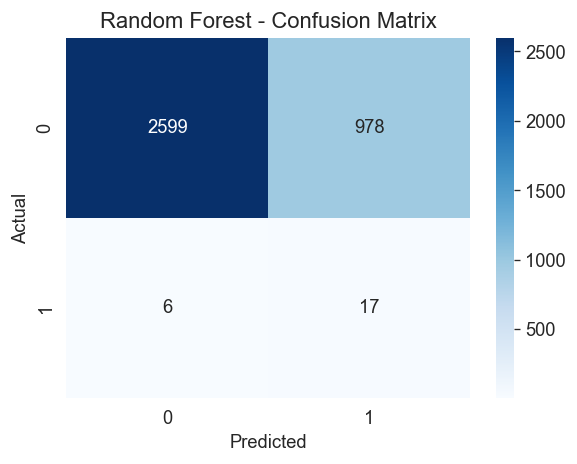

In [4]:
print("Training Random Forest...")
scale_pos_weight = (y_train == 0).sum() / max(1, (y_train == 1).sum())
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train, y_train)

rf_metrics = evaluate_model(rf_model, X_test, y_test, "Random Forest")

Training XGBoost...


--- XGBoost Performance ---
** Optimal Threshold for Youden's J: 0.034 **
Balanced Accuracy: 0.7243
Precision: 0.0202
Recall   : 0.6522
F1 Score : 0.0392
ROC AUC  : 0.7700

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.80      0.89      3577
           1       0.02      0.65      0.04        23

    accuracy                           0.80      3600
   macro avg       0.51      0.72      0.46      3600
weighted avg       0.99      0.80      0.88      3600



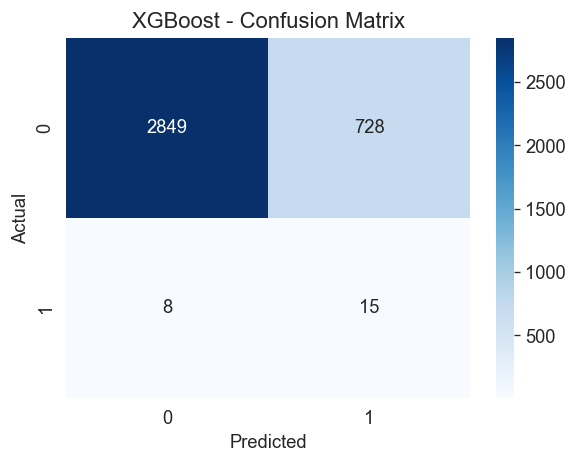

In [5]:
print("Training XGBoost...")
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight, min_child_weight=1)
xgb_model.fit(X_train, y_train)

xgb_metrics = evaluate_model(xgb_model, X_test, y_test, "XGBoost")

Training LightGBM...


[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Number of positive: 4295, number of negative: 14318
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001435 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 18613, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
--- LightGBM Performance ---
** Optimal Threshold for Youden's J: 0.025 **
Balanced Accuracy: 0.8033
Precision: 0.0346
Recall   : 0.7391
F1 Score : 0.0661
ROC AUC  : 0.7667

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.87      0.93      3577
           1       0.03      0.74      0.07        23

    accuracy                           0.87      3600
   macro avg       0.52      0.80      0.50      3600
weighted avg       0.99      0.87      0.92      3600



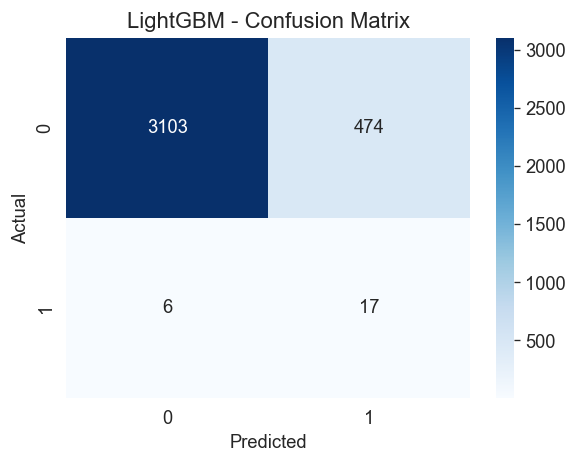

In [6]:
print("Training LightGBM...")
lgb_model = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, class_weight='balanced', min_data_in_leaf=5)
lgb_model.fit(X_train, y_train)

lgb_metrics = evaluate_model(lgb_model, X_test, y_test, "LightGBM")

### 5. Ensemble Stacking
Using Soft Voting Classifier to combine RF, XGB, and LGBM models.

Training Ensemble Model...


[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Number of positive: 4295, number of negative: 14318
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001003 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 18613, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
--- Ensemble Model Performance ---
** Optimal Threshold for Youden's J: 0.017 **
Balanced Accuracy: 0.7772
Precision: 0.0216
Recall   : 0.7826
F1 Score : 0.0420
ROC AUC  : 0.7987

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.77      0.87      3577
           1       0.02      0.78      0.04        23

    accuracy                           0.77      3600
   macro avg       0.51      0.78      0.46      3600
weighted avg       0.99      0.77      0.87      3600



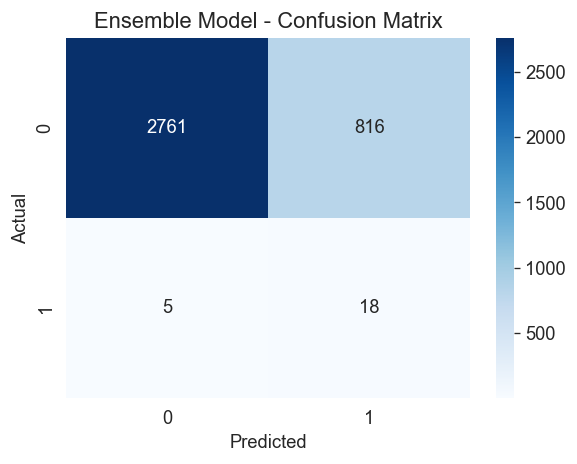

In [7]:
from sklearn.ensemble import VotingClassifier

print("Training Ensemble Model...")
ensemble_model = VotingClassifier(estimators=[
    ('rf', rf_model),
    ('xgb', xgb_model),
    ('lgb', lgb_model)
], voting='soft')

ensemble_model.fit(X_train, y_train)
ensemble_metrics = evaluate_model(ensemble_model, X_test, y_test, "Ensemble Model")

# Save ensemble model
with open(models_dir / 'ensemble_model.pkl', 'wb') as f:
    pickle.dump(ensemble_model, f)


## 4. Compare Models and Evaluate ROC

Model Comparison Summary:


,accuracy,precision,recall,f1,auc
LightGBM,0.803309,0.034623,0.73913,0.066148,0.766698
XGBoost,0.724326,0.020188,0.652174,0.039164,0.769992
Random Forest,0.732858,0.017085,0.73913,0.033399,0.768825


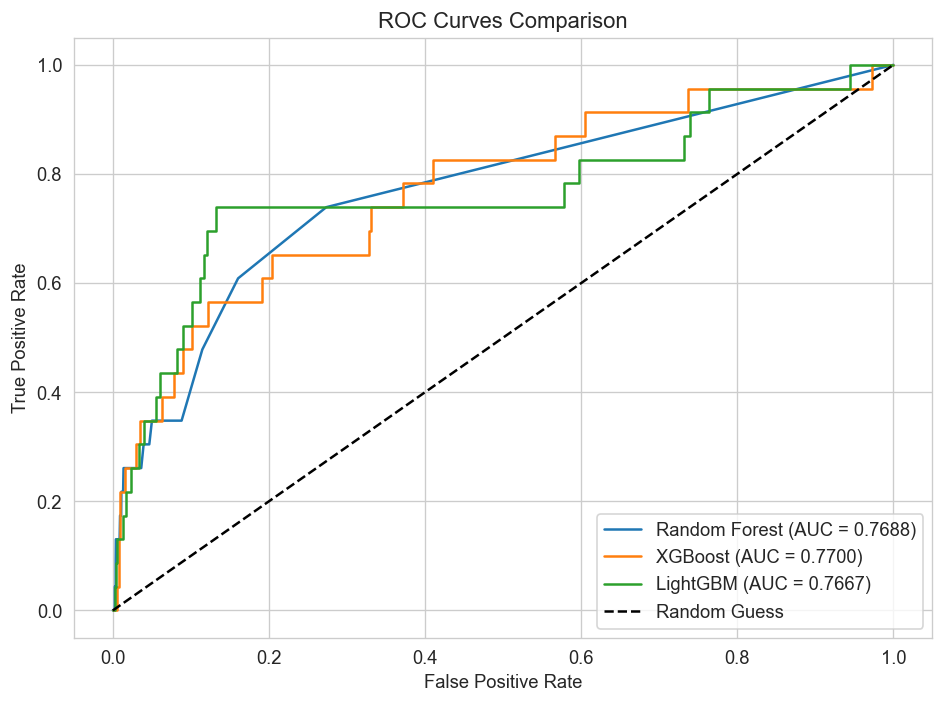

In [8]:
# Compare all models gracefully
models_comparison = pd.DataFrame({
    'Random Forest': rf_metrics,
    'XGBoost': xgb_metrics,
    'LightGBM': lgb_metrics
}).T.drop(columns=['y_prob'])

print("Model Comparison Summary:")
display(models_comparison.sort_values(by='f1', ascending=False))

# Plot ROC Curves
plt.figure(figsize=(8, 6))

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_metrics['y_prob'])
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_metrics['y_prob'])
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, lgb_metrics['y_prob'])

plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {rf_metrics['auc']:.4f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {xgb_metrics['auc']:.4f})")
plt.plot(fpr_lgb, tpr_lgb, label=f"LightGBM (AUC = {lgb_metrics['auc']:.4f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.title('ROC Curves Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(figures_dir / 'roc_curves_comparison.png')
plt.show()

## 5. Persistence
Save the trained models locally into the `models/` directory so they can be loaded by evaluating scripts or the deployment dashboard.

In [9]:
with open(models_dir / 'rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open(models_dir / 'xgb_flood_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open(models_dir / 'lgb_model.pkl', 'wb') as f:
    pickle.dump(lgb_model, f)

# Save the scaler as well (it was fitted in notebook 06 and saved in data/processed)
if (processed_dir / 'scaler.pkl').exists():
    import shutil
    shutil.copy(processed_dir / 'scaler.pkl', models_dir / 'scaler.pkl')
    print(f"Scaler successfully copied to root: {models_dir}")
    
    # Also copy to backend/models for immediate Docker use
    backend_models = project_root / 'backend' / 'models'
    if backend_models.exists():
        shutil.copy(models_dir / 'rf_model.pkl', backend_models / 'rf_model.pkl')
        shutil.copy(models_dir / 'xgb_flood_model.pkl', backend_models / f'xgb_flood_model.pkl')
        shutil.copy(models_dir / 'lgb_model.pkl', backend_models / 'lgb_model.pkl')
        shutil.copy(models_dir / 'scaler.pkl', backend_models / 'scaler.pkl')
        print(f"All artifacts copied to backend: {backend_models}")
else:
    print("Warning: scaler.pkl not found in processed_dir. Make sure notebook 06 was run.")

print(f"Models successfully saved to: {models_dir}")

Scaler successfully copied to root: C:\Users\linga\Music\Chikwawa-Flood-Prediction\models
All artifacts copied to backend: C:\Users\linga\Music\Chikwawa-Flood-Prediction\backend\models
Models successfully saved to: C:\Users\linga\Music\Chikwawa-Flood-Prediction\models
